# 第五次作业：MLP 分类与回归

本 Notebook 参考课件 **第 5 章全连接神经网络** 中 5.2 和 5.3 的思路，分别实现一个 MLP 分类任务和一个 MLP 回归任务。

1. 数据准备：加载数据、划分训练/验证/测试集、标准化或归一化、构造 `DataLoader`。
2. 模型构建：使用 PyTorch `nn.Module` 定义多层感知机 MLP。
3. 模型训练：完成前向传播、损失计算、反向传播、参数更新。
4. 模型预测：在测试集上输出预测结果。
5. 损失函数：分类使用交叉熵损失 `CrossEntropyLoss`，回归使用均方误差损失 `MSELoss`。
6. 指标计算：分类计算准确率和混淆矩阵；回归计算 MSE、RMSE、MAE 和 R2。

## 1. 导入库与公共设置

这一节完成三件事：

- 导入 PyTorch、sklearn、matplotlib 等需要的库。
- 固定随机种子，让每次训练结果尽量可复现。
- 自动选择 GPU 或 CPU，并创建 `outputs` 目录保存图片、模型参数和结果文本。

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


def set_seed(seed=42):
    """固定常见随机源，减少每次运行之间的波动。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("PyTorch 版本：", torch.__version__)
print("运行设备：", DEVICE)
print("输出目录：", OUTPUT_DIR.resolve())

PyTorch 版本： 2.11.0+cu128
运行设备： cuda
输出目录： D:\steven\hw\rgzn\hw5\outputs


## 2. 分类任务：用 MLP 识别手写数字

分类任务使用 sklearn 自带的 `digits` 数据集。它包含 1797 张 `8 x 8` 灰度手写数字图像，每个样本属于 0 到 9 中的一个类别。

这里把每张图像展平为 64 维向量，输入到全连接神经网络中。因为像素值范围是 0 到 16，所以先除以 16 做归一化，让输入落在 0 到 1 附近，便于模型训练。

In [2]:
digits = load_digits()

X_cls = digits.data.astype(np.float32) / 16.0
y_cls = digits.target.astype(np.int64)
class_names = [str(i) for i in range(10)]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val,
)

train_cls_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
val_cls_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long),
)
test_cls_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long),
)

train_cls_loader = DataLoader(train_cls_ds, batch_size=64, shuffle=True, num_workers=0)
val_cls_loader = DataLoader(val_cls_ds, batch_size=128, shuffle=False, num_workers=0)
test_cls_loader = DataLoader(test_cls_ds, batch_size=128, shuffle=False, num_workers=0)

print(f"分类数据集总样本数：{len(X_cls)}")
print(f"训练集：{len(train_cls_ds)}，验证集：{len(val_cls_ds)}，测试集：{len(test_cls_ds)}")
print(f"输入特征维度：{X_cls.shape[1]}，类别数：{len(class_names)}")

class_count = pd.Series(y_train, name="digit").value_counts().sort_index()
display(class_count.to_frame("训练集样本数"))

分类数据集总样本数：1797
训练集：1149，验证集：288，测试集：360
输入特征维度：64，类别数：10


,训练集样本数
digit,
0,113
1,117
2,114
3,117
4,116
5,116
6,116
7,114
8,111


### 2.1 查看分类样本

训练前先展示部分样本，确认数据读取和标签对应关系正确。下面显示的是原始 `8 x 8` 图像，模型实际接收的是展平后的 64 维向量。

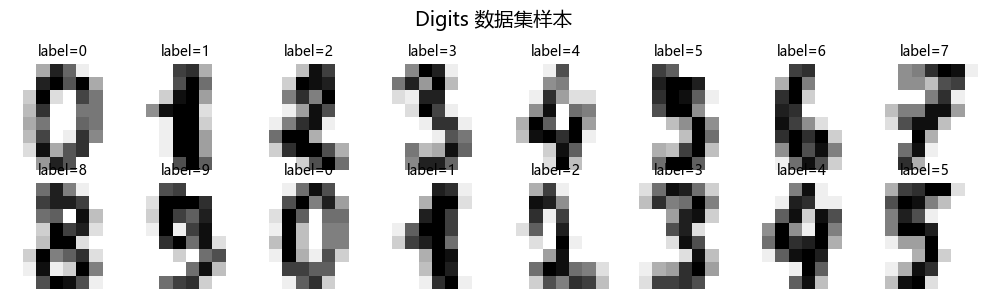

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, image, label in zip(axes.ravel(), digits.images[:16], digits.target[:16]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"label={label}", fontsize=10)
    ax.axis("off")

fig.suptitle("Digits 数据集样本", fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 搭建 MLP 分类模型

多层感知机由若干个全连接层和非线性激活函数组成。这里的结构是：

`64 -> 128 -> 64 -> 10`

- 输入层：64 个特征，对应 `8 x 8` 图像展平后的像素。
- 隐藏层：使用 `Linear + ReLU + Dropout` 提高非线性表达能力并减轻过拟合。
- 输出层：10 个神经元，对应 10 个数字类别。
- 损失函数：`CrossEntropyLoss` 内部会完成 softmax 和负对数似然计算，所以模型输出 logits 即可。

In [4]:
class DigitsMLPClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden1=128, hidden2=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(p=0.20),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p=0.10),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


cls_model = DigitsMLPClassifier().to(DEVICE)
print(cls_model)

DigitsMLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


### 2.3 定义分类训练与评估函数

训练一个 epoch 的逻辑如下：

1. 把一个 batch 的特征和标签移动到运行设备。
2. 前向传播得到每个类别的 logits。
3. 用交叉熵损失比较预测结果和真实标签。
4. 训练阶段执行 `backward()` 和 `optimizer.step()` 更新参数。
5. 统计整轮平均 loss 和 accuracy。

验证/测试阶段不更新参数，只计算 loss 和 accuracy。

In [5]:
def run_classification_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = batch_y.size(0)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * batch_size
            total_correct += (preds == batch_y).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_classifier(model, train_loader, val_loader, epochs=40):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = []
    best_val_acc = 0.0
    best_state = None
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_classification_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_classification_epoch(model, val_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            }
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start
    print(f"分类模型训练完成，用时 {elapsed:.1f} 秒；最佳验证准确率：{best_val_acc:.4f}")
    return pd.DataFrame(history), best_val_acc

### 2.4 训练分类模型

下面开始训练 MLP 分类模型。正常情况下，训练 loss 会逐渐下降，训练/验证准确率会逐渐上升。

In [6]:
set_seed(42)
cls_model = DigitsMLPClassifier().to(DEVICE)
cls_history, best_cls_val_acc = train_classifier(
    cls_model,
    train_cls_loader,
    val_cls_loader,
    epochs=40,
)

display(cls_history.tail())

Epoch 01/40 | train_loss=2.2531, train_acc=0.2785 | val_loss=2.1661, val_acc=0.6458
Epoch 05/40 | train_loss=0.8306, train_acc=0.7963 | val_loss=0.5877, val_acc=0.9167


Epoch 10/40 | train_loss=0.3231, train_acc=0.9121 | val_loss=0.2311, val_acc=0.9549
Epoch 15/40 | train_loss=0.1969, train_acc=0.9443 | val_loss=0.1499, val_acc=0.9618


Epoch 20/40 | train_loss=0.1474, train_acc=0.9626 | val_loss=0.1182, val_acc=0.9653
Epoch 25/40 | train_loss=0.1223, train_acc=0.9669 | val_loss=0.1027, val_acc=0.9653


Epoch 30/40 | train_loss=0.0933, train_acc=0.9739 | val_loss=0.0953, val_acc=0.9722
Epoch 35/40 | train_loss=0.0883, train_acc=0.9782 | val_loss=0.0830, val_acc=0.9757


Epoch 40/40 | train_loss=0.0692, train_acc=0.9800 | val_loss=0.0760, val_acc=0.9722
分类模型训练完成，用时 1.5 秒；最佳验证准确率：0.9792


,epoch,train_loss,train_acc,val_loss,val_acc
35,36,0.088547,0.973890,0.081682,0.975694
36,37,0.073625,0.981723,0.087152,0.965278
37,38,0.074371,0.982594,0.081111,0.979167
38,39,0.069284,0.982594,0.086137,0.972222
39,40,0.069213,0.979983,0.076031,0.972222


### 2.5 可视化分类训练过程

左图观察 loss 是否下降，右图观察 accuracy 是否提升。训练集和验证集曲线都比较稳定时，说明模型确实学到了可泛化的模式。

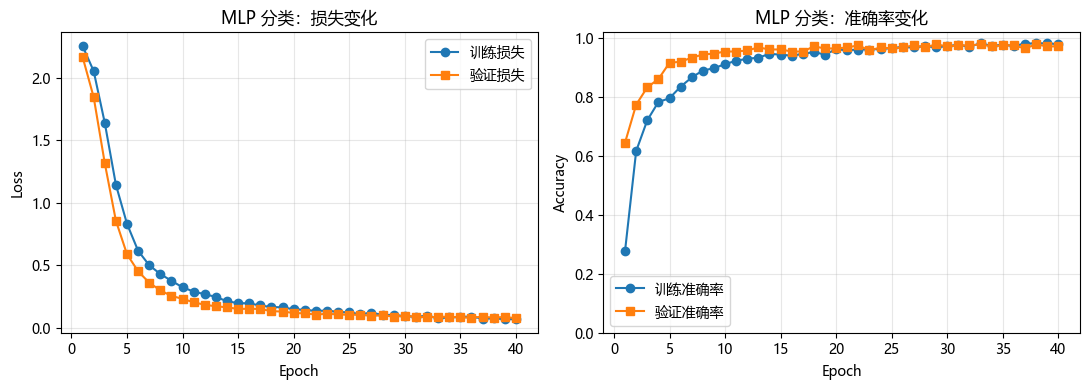

分类训练曲线已保存： D:\steven\hw\rgzn\hw5\outputs\classification_training_curve.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(cls_history["epoch"], cls_history["train_loss"], marker="o", label="训练损失")
axes[0].plot(cls_history["epoch"], cls_history["val_loss"], marker="s", label="验证损失")
axes[0].set_title("MLP 分类：损失变化")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(cls_history["epoch"], cls_history["train_acc"], marker="o", label="训练准确率")
axes[1].plot(cls_history["epoch"], cls_history["val_acc"], marker="s", label="验证准确率")
axes[1].set_title("MLP 分类：准确率变化")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
curve_path = OUTPUT_DIR / "classification_training_curve.png"
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("分类训练曲线已保存：", curve_path.resolve())

### 2.6 分类测试集预测与准确率计算

测试集在训练过程中没有参与参数更新，也没有参与选择最佳 epoch，因此可以用来估计模型面对新样本时的泛化能力。

In [8]:
def collect_classification_predictions(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            logits = model(batch_x)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(batch_y.numpy().tolist())

    return np.array(all_targets), np.array(all_preds)


y_test_true, y_test_pred = collect_classification_predictions(cls_model, test_cls_loader)
test_cls_acc = accuracy_score(y_test_true, y_test_pred)

print(f"分类测试集准确率：{test_cls_acc:.4f}")

report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report).T.round(4))

分类测试集准确率：0.9750


,precision,recall,f1-score,support
0,1.0000,0.9722,0.9859,36.000
1,0.9167,0.9167,0.9167,36.000
2,1.0000,1.0000,1.0000,35.000
3,1.0000,0.9730,0.9863,37.000
4,0.9730,1.0000,0.9863,36.000
5,0.9737,1.0000,0.9867,37.000
6,0.9730,1.0000,0.9863,36.000
7,1.0000,1.0000,1.0000,36.000
8,0.9143,0.9143,0.9143,35.000
9,1.0000,0.9722,0.9859,36.000


### 2.7 混淆矩阵与预测样例

混淆矩阵的横轴是预测类别，纵轴是真实类别。对角线越亮，说明预测正确的样本越多；非对角线位置表示被混淆的类别。

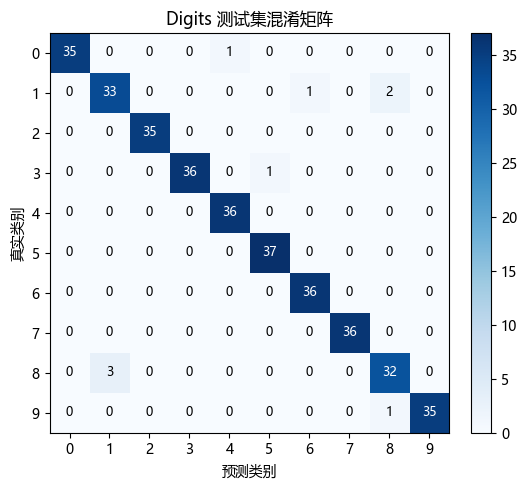

分类混淆矩阵已保存： D:\steven\hw\rgzn\hw5\outputs\classification_confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Digits 测试集混淆矩阵")
ax.set_xlabel("预测类别")
ax.set_ylabel("真实类别")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() * 0.55 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = OUTPUT_DIR / "classification_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("分类混淆矩阵已保存：", cm_path.resolve())

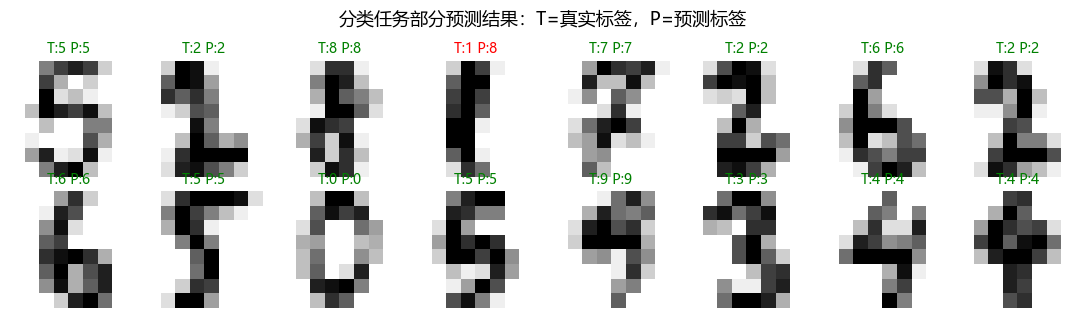

In [10]:
sample_indices = np.arange(16)
sample_images = X_test[sample_indices].reshape(-1, 8, 8) * 16.0
sample_true = y_test_true[sample_indices]
sample_pred = y_test_pred[sample_indices]

fig, axes = plt.subplots(2, 8, figsize=(11, 3.2))
for ax, image, true_label, pred_label in zip(axes.ravel(), sample_images, sample_true, sample_pred):
    ax.imshow(image, cmap="gray_r")
    title_color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T:{true_label} P:{pred_label}", color=title_color, fontsize=10)
    ax.axis("off")

fig.suptitle("分类任务部分预测结果：T=真实标签，P=预测标签", fontsize=13)
plt.tight_layout()
plt.show()

## 3. 回归任务：用 MLP 预测糖尿病进展指标

回归任务使用 sklearn 自带的 `diabetes` 数据集。它包含 442 个样本，每个样本有 10 个数值特征，目标值是一个连续的疾病进展指标。

回归与分类最大的区别是：

- 分类输出的是类别，常用交叉熵损失和准确率。
- 回归输出的是连续数值，常用均方误差损失，并用 MSE、RMSE、MAE、R2 等指标评价。

为了让训练更稳定，这里只用训练集拟合 `StandardScaler`，分别对输入特征和目标值做标准化；最后计算指标时再把预测值还原到原始尺度。

In [11]:
diabetes = load_diabetes()

X_reg = diabetes.data.astype(np.float32)
y_reg = diabetes.target.astype(np.float32).reshape(-1, 1)

X_train_val_reg, X_test_reg, y_train_val_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42,
)

X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_train_val_reg,
    y_train_val_reg,
    test_size=0.20,
    random_state=42,
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_reg_scaled = x_scaler.fit_transform(X_train_reg).astype(np.float32)
X_val_reg_scaled = x_scaler.transform(X_val_reg).astype(np.float32)
X_test_reg_scaled = x_scaler.transform(X_test_reg).astype(np.float32)

y_train_reg_scaled = y_scaler.fit_transform(y_train_reg).astype(np.float32)
y_val_reg_scaled = y_scaler.transform(y_val_reg).astype(np.float32)
y_test_reg_scaled = y_scaler.transform(y_test_reg).astype(np.float32)

train_reg_ds = TensorDataset(
    torch.tensor(X_train_reg_scaled, dtype=torch.float32),
    torch.tensor(y_train_reg_scaled, dtype=torch.float32),
)
val_reg_ds = TensorDataset(
    torch.tensor(X_val_reg_scaled, dtype=torch.float32),
    torch.tensor(y_val_reg_scaled, dtype=torch.float32),
)
test_reg_ds = TensorDataset(
    torch.tensor(X_test_reg_scaled, dtype=torch.float32),
    torch.tensor(y_test_reg_scaled, dtype=torch.float32),
)

train_reg_loader = DataLoader(train_reg_ds, batch_size=32, shuffle=True, num_workers=0)
val_reg_loader = DataLoader(val_reg_ds, batch_size=128, shuffle=False, num_workers=0)
test_reg_loader = DataLoader(test_reg_ds, batch_size=128, shuffle=False, num_workers=0)

print(f"回归数据集总样本数：{len(X_reg)}")
print(f"训练集：{len(train_reg_ds)}，验证集：{len(val_reg_ds)}，测试集：{len(test_reg_ds)}")
print(f"输入特征维度：{X_reg.shape[1]}，输出维度：1")
display(pd.DataFrame(y_reg, columns=["target"]).describe().round(2))

回归数据集总样本数：442
训练集：282，验证集：71，测试集：89
输入特征维度：10，输出维度：1


,target
count,442.00
mean,152.13
std,77.09
min,25.00
25%,87.00
50%,140.50
75%,211.50
max,346.00


### 3.1 查看回归目标分布

回归任务的标签是连续值，不是离散类别。目标值分布可以帮助我们理解模型要拟合的数值范围。

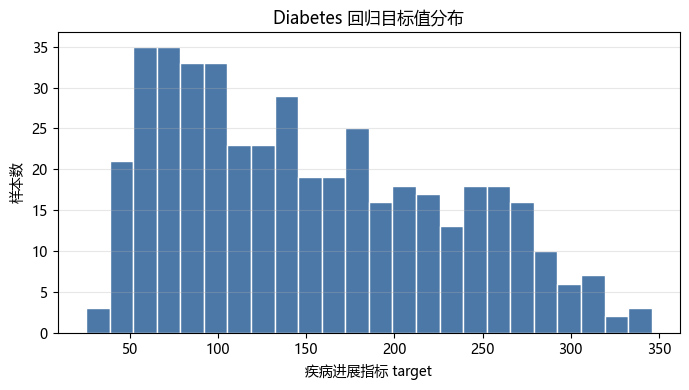

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(y_reg.ravel(), bins=24, color="#4C78A8", edgecolor="white")
plt.title("Diabetes 回归目标值分布")
plt.xlabel("疾病进展指标 target")
plt.ylabel("样本数")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 搭建 MLP 回归模型

回归模型仍然使用全连接网络，但输出层只有 1 个神经元，表示预测出的连续数值。结构为：

`10 -> 64 -> 32 -> 1`

输出层不使用 softmax，因为回归不是在类别概率之间做选择，而是直接拟合一个实数。

In [13]:
class DiabetesMLPRegressor(nn.Module):
    def __init__(self, input_dim=10, hidden1=64, hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


reg_model = DiabetesMLPRegressor().to(DEVICE)
print(reg_model)

DiabetesMLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 3.3 定义回归训练与评估函数

回归训练流程和分类任务相同，仍然是前向传播、计算损失、反向传播、更新参数。不同点在于：

- 损失函数使用 `MSELoss`，衡量预测值和真实连续值之间的均方误差。
- 评价时不仅看 loss，还会把预测值还原到原始尺度后计算 MSE、RMSE、MAE、R2。

In [14]:
def run_regression_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            preds = model(batch_x)
            loss = criterion(preds, batch_y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = batch_y.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples


def train_regressor(model, train_loader, val_loader, epochs=220):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=8e-4, weight_decay=1e-4)

    history = []
    best_val_loss = float("inf")
    best_state = None
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = run_regression_epoch(model, train_loader, criterion, optimizer)
        val_loss = run_regression_epoch(model, val_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % 25 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:03d}/{epochs} | "
                f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start
    print(f"回归模型训练完成，用时 {elapsed:.1f} 秒；最佳验证 MSELoss：{best_val_loss:.4f}")
    return pd.DataFrame(history), best_val_loss

### 3.4 训练回归模型

由于 `diabetes` 数据集样本较少，回归任务通常比 digits 分类更容易出现验证集波动，所以训练时保存验证损失最低的模型参数。

In [15]:
set_seed(42)
reg_model = DiabetesMLPRegressor().to(DEVICE)
reg_history, best_reg_val_loss = train_regressor(
    reg_model,
    train_reg_loader,
    val_reg_loader,
    epochs=220,
)

display(reg_history.tail())

Epoch 001/220 | train_loss=0.8658, val_loss=0.7201


Epoch 025/220 | train_loss=0.3933, val_loss=0.5257


Epoch 050/220 | train_loss=0.3207, val_loss=0.5611


Epoch 075/220 | train_loss=0.2510, val_loss=0.5655


Epoch 100/220 | train_loss=0.1893, val_loss=0.6241


...

Epoch 150/220 | train_loss=0.0949, val_loss=0.7792


Epoch 175/220 | train_loss=0.0637, val_loss=0.8399


Epoch 200/220 | train_loss=0.0464, val_loss=0.8715


Epoch 220/220 | train_loss=0.0331, val_loss=0.9378
回归模型训练完成，用时 2.4 秒；最佳验证 MSELoss：0.4699


,epoch,train_loss,val_loss
215,216,0.037015,0.919250
216,217,0.035039,0.912987
217,218,0.034226,0.919298
218,219,0.032661,0.935110
219,220,0.033131,0.937803


### 3.5 可视化回归训练过程

这里的 loss 是在标准化后的目标值上计算的 MSE。只要训练损失整体下降，说明模型在逐步拟合训练数据；验证损失用于观察泛化效果。

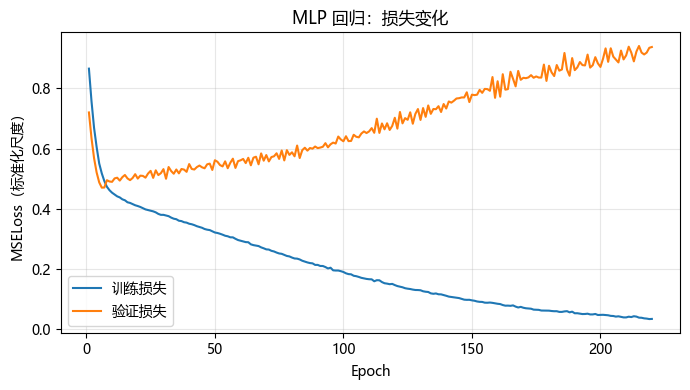

回归训练曲线已保存： D:\steven\hw\rgzn\hw5\outputs\regression_training_curve.png


In [16]:
plt.figure(figsize=(7, 4))
plt.plot(reg_history["epoch"], reg_history["train_loss"], label="训练损失")
plt.plot(reg_history["epoch"], reg_history["val_loss"], label="验证损失")
plt.title("MLP 回归：损失变化")
plt.xlabel("Epoch")
plt.ylabel("MSELoss（标准化尺度）")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

reg_curve_path = OUTPUT_DIR / "regression_training_curve.png"
plt.savefig(reg_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("回归训练曲线已保存：", reg_curve_path.resolve())

### 3.6 回归测试集预测与指标计算

测试阶段先得到标准化尺度上的预测值，再用 `y_scaler.inverse_transform` 还原为原始目标值尺度。这样 MSE、RMSE、MAE 更容易解释。

In [17]:
def collect_regression_predictions(model, loader, y_scaler):
    model.eval()
    preds_scaled = []
    targets_scaled = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            preds = model(batch_x).cpu().numpy()
            preds_scaled.append(preds)
            targets_scaled.append(batch_y.numpy())

    preds_scaled = np.vstack(preds_scaled)
    targets_scaled = np.vstack(targets_scaled)

    preds = y_scaler.inverse_transform(preds_scaled).ravel()
    targets = y_scaler.inverse_transform(targets_scaled).ravel()
    return targets, preds


y_reg_true, y_reg_pred = collect_regression_predictions(reg_model, test_reg_loader, y_scaler)

reg_mse = mean_squared_error(y_reg_true, y_reg_pred)
reg_rmse = float(np.sqrt(reg_mse))
reg_mae = mean_absolute_error(y_reg_true, y_reg_pred)
reg_r2 = r2_score(y_reg_true, y_reg_pred)

reg_metrics = pd.DataFrame(
    {
        "指标": ["MSE", "RMSE", "MAE", "R2"],
        "数值": [reg_mse, reg_rmse, reg_mae, reg_r2],
    }
)
display(reg_metrics.round(4))

print(f"回归测试集 MSE：{reg_mse:.4f}")
print(f"回归测试集 RMSE：{reg_rmse:.4f}")
print(f"回归测试集 MAE：{reg_mae:.4f}")
print(f"回归测试集 R2：{reg_r2:.4f}")

,指标,数值
0,MSE,3030.7566
1,RMSE,55.0523
2,MAE,44.3658
3,R2,0.4280


回归测试集 MSE：3030.7566
回归测试集 RMSE：55.0523
回归测试集 MAE：44.3658
回归测试集 R2：0.4280


### 3.7 回归预测散点图与样例

散点图中，横轴是真实值，纵轴是预测值。点越接近虚线 `y=x`，说明预测越准确。

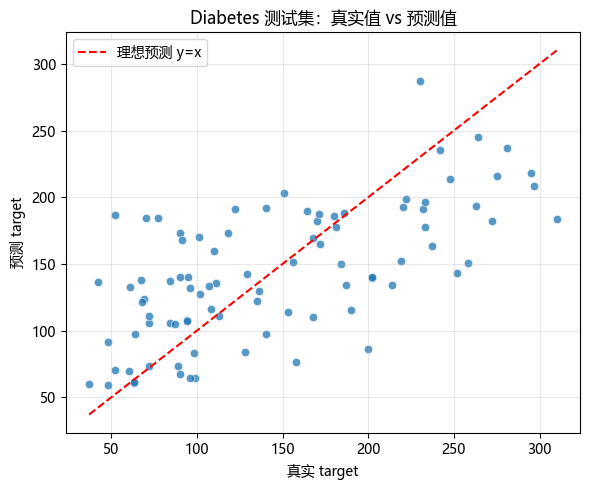

回归预测散点图已保存： D:\steven\hw\rgzn\hw5\outputs\regression_prediction_scatter.png


In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(y_reg_true, y_reg_pred, alpha=0.75, edgecolor="white", linewidth=0.5)
min_value = min(y_reg_true.min(), y_reg_pred.min())
max_value = max(y_reg_true.max(), y_reg_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], "--", color="red", label="理想预测 y=x")
plt.title("Diabetes 测试集：真实值 vs 预测值")
plt.xlabel("真实 target")
plt.ylabel("预测 target")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

scatter_path = OUTPUT_DIR / "regression_prediction_scatter.png"
plt.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

print("回归预测散点图已保存：", scatter_path.resolve())

In [19]:
pred_table = pd.DataFrame(
    {
        "真实值": y_reg_true[:12],
        "预测值": y_reg_pred[:12],
        "绝对误差": np.abs(y_reg_true[:12] - y_reg_pred[:12]),
    }
)
display(pred_table.round(2))

,真实值,预测值,绝对误差
0,219.0,152.509995,66.489998
1,70.0,184.360001,114.360001
2,202.0,139.610001,62.389999
3,230.0,287.410004,57.410000
4,111.0,135.440002,24.440001
5,84.0,105.589996,21.590000
6,242.0,235.759995,6.240000
7,272.0,182.119995,89.879997
8,94.0,107.540001,13.540000
9,96.0,131.580002,35.580002


## 4. 保存模型参数与运行结果

这一节把训练好的模型参数、关键指标和代码逻辑说明保存下来，方便提交作业和录制展示视频时引用。

In [20]:
cls_model_path = OUTPUT_DIR / "mlp_digits_classifier_state_dict.pth"
reg_model_path = OUTPUT_DIR / "mlp_diabetes_regressor_state_dict.pth"

torch.save(cls_model.state_dict(), cls_model_path)
torch.save(reg_model.state_dict(), reg_model_path)

results_text = f"""第五次作业：MLP 分类与回归

一、分类任务
数据集：sklearn digits 手写数字数据集
模型结构：64 -> 128 -> 64 -> 10 的多层感知机
损失函数：CrossEntropyLoss
评价指标：Accuracy、classification report、confusion matrix
最佳验证准确率：{best_cls_val_acc:.4f}
测试集准确率：{test_cls_acc:.4f}

二、回归任务
数据集：sklearn diabetes 糖尿病进展指标数据集
模型结构：10 -> 64 -> 32 -> 1 的多层感知机
损失函数：MSELoss
评价指标：MSE、RMSE、MAE、R2
最佳验证 MSELoss（标准化尺度）：{best_reg_val_loss:.4f}
测试集 MSE：{reg_mse:.4f}
测试集 RMSE：{reg_rmse:.4f}
测试集 MAE：{reg_mae:.4f}
测试集 R2：{reg_r2:.4f}

三、代码逻辑说明
1. 数据准备：分类任务将 8x8 图像展平并归一化；回归任务对训练集拟合 StandardScaler，再转换验证集和测试集，避免数据泄漏。
2. 模型构建：两个任务都使用 nn.Module 搭建全连接 MLP，隐藏层使用 ReLU 增加非线性表达能力。
3. 模型训练：每个 batch 完成前向传播、损失计算、梯度清零、反向传播和优化器更新。
4. 模型预测：训练结束后只在测试集上预测，分类取 logits 最大值作为类别，回归直接输出连续值。
5. 损失与指标：分类使用交叉熵和准确率；回归使用均方误差，并额外计算 RMSE、MAE、R2。
"""

results_path = OUTPUT_DIR / "results_summary.txt"
results_path.write_text(results_text, encoding="utf-8")

print(results_text)
print("分类模型参数已保存：", cls_model_path.resolve())
print("回归模型参数已保存：", reg_model_path.resolve())
print("运行结果文本已保存：", results_path.resolve())

第五次作业：MLP 分类与回归

一、分类任务
数据集：sklearn digits 手写数字数据集
模型结构：64 -> 128 -> 64 -> 10 的多层感知机
损失函数：CrossEntropyLoss
评价指标：Accuracy、classification report、confusion matrix
最佳验证准确率：0.9792
测试集准确率：0.9750

二、回归任务
数据集：sklearn diabetes 糖尿病进展指标数据集
模型结构：10 -> 64 -> 32 -> 1 的多层感知机
损失函数：MSELoss
评价指标：MSE、RMSE、MAE、R2
最佳验证 MSELoss（标准化尺度）：0.4699
测试集 MSE：3030.7566
测试集 RMSE：55.0523
测试集 MAE：44.3658
测试集 R2：0.4280

三、代码逻辑说明
1. 数据准备：分类任务将 8x8 图像展平并归一化；回归任务对训练集拟合 StandardScaler，再转换验证集和测试集，避免数据泄漏。
2. 模型构建：两个任务都使用 nn.Module 搭建全连接 MLP，隐藏层使用 ReLU 增加非线性表达能力。
3. 模型训练：每个 batch 完成前向传播、损失计算、梯度清零、反向传播和优化器更新。
4. 模型预测：训练结束后只在测试集上预测，分类取 logits 最大值作为类别，回归直接输出连续值。
5. 损失与指标：分类使用交叉熵和准确率；回归使用均方误差，并额外计算 RMSE、MAE、R2。

分类模型参数已保存： D:\steven\hw\rgzn\hw5\outputs\mlp_digits_classifier_state_dict.pth
回归模型参数已保存： D:\steven\hw\rgzn\hw5\outputs\mlp_diabetes_regressor_state_dict.pth
运行结果文本已保存： D:\steven\hw\rgzn\hw5\outputs\results_summary.txt


## 5. 总结

本作业完整实现了两个 MLP 任务：

- **分类**：Digits 手写数字识别，输入是 64 维像素特征，输出是 10 个类别，核心指标是准确率。
- **回归**：Diabetes 连续指标预测，输入是 10 维数值特征，输出是 1 个连续值，核心指标是 MSE、RMSE、MAE、R2。

两者的共同点是都使用全连接层、ReLU、mini-batch 训练和反向传播；不同点是输出层维度、损失函数和评价指标不同。分类问题关注“预测类别是否正确”，回归问题关注“预测数值和真实数值相差多少”。